<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%202/Econ_3916_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Manual DGP Simulation
import numpy as np
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [3]:
def calculate_mad(data):
  # 1. Calculate the Median of the data
  data = np.array(data)
  sorted_data = np.sort(data)
  n = len(sorted_data)
  mid = n // 2
  if n % 2 == 1:
      median = sorted_data[mid]
  else:
      median = (sorted_data[mid - 1] + sorted_data[mid]) / 2

  # 2. Calculate Absolute Deviations (|x - median|)
  absolute_deviations = np.abs(data - median)

  # 3. Return the Median of those deviations
  sorted_absolute_deviations = np.sort(absolute_deviations)
  m = len(sorted_absolute_deviations)
  mid2 = m // 2
  if m % 2 == 1:
    mad = sorted_absolute_deviations[mid2]
  else:
    mad = (sorted_absolute_deviations[mid2 - 1] + sorted_absolute_deviations[mid2]) / 2
  return mad

MAD = calculate_mad(latency_logs)
print("MAD:", MAD)
SD = np.std(latency_logs)
print("SD:", SD)

MAD: 8.0
SD: 487.6798079847063


SD uses the mean and squared deviations, so the 20 spike latencies contribute huge squared errors and dominate the variance, making SD “explode.” MAD is based on the median of absolute deviations, so with 980/1000 points in the normal range, the median barely changes. That’s why SD becomes very large while MAD stays stable.

In [4]:
# P(Cheater | Flagged) = P(Cheater) * P(Flagged | Cheater) / P(Flagged)
# sensitivity = 98% = P(flagged | cheater)
# specificity = 98% = P(not flagged | not cheater)
# prior = P(cheater)
# p(flagged) = P(flagged | cheater) * P(cheater) + P(flagged | not cheater) * P(not cheater)
# p(flagged) = sensitivity * prior + (1-specificity) * (1-prior)
# p(flagged) = numerator + p_flag_given_not_cheater * (1-prior)
sensitivity = 0.98
specificity = 0.98

def bayesian_audit(prior, sensitivity, specificity):
  p_flag_given_cheater = sensitivity
  p_flag_given_not_cheater = 1 - specificity

  numerator = prior * p_flag_given_cheater
  denominator = numerator + p_flag_given_not_cheater * (1-prior)

  return numerator / denominator

scenario_a = bayesian_audit(0.5, sensitivity, specificity)
scenario_b = bayesian_audit(0.05, sensitivity, specificity)
scenario_c = bayesian_audit(0.001, sensitivity, specificity)

print("Scenario A (Bootcamp):", scenario_a)
print("Scenario B (Econ Class):", scenario_b)
print("Scenario C (Honors Seminar):", scenario_c)


Scenario A (Bootcamp): 0.98
Scenario B (Econ Class): 0.7205882352941175
Scenario C (Honors Seminar): 0.04675572519083965


In [5]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250,49750])
expected = np.array([50000,50000])

chi_square = 0
for x,y in zip(observed,expected):
  chi_square += (x - y)** 2 / y
print("Chi-Square is:", chi_square)

if chi_square > 3.84:
  print("The experiment is INVALID due to engineering bias.")
else:
  print("The experiment is VALID")

Chi-Square is: 2.5
The experiment is VALID


=== Survivorship Bias Demo (Peak Market Cap) ===
Total tokens simulated: 10,000
Survivors (top 1.00%): 100
Pareto alpha (shape): 2.0
Mean peak market cap (ALL / 'Graveyard'):      1,974,417.82
Mean peak market cap (SURVIVORS / top 1% only): 18,479,749.42
Survivors mean ÷ All mean: 9.36x


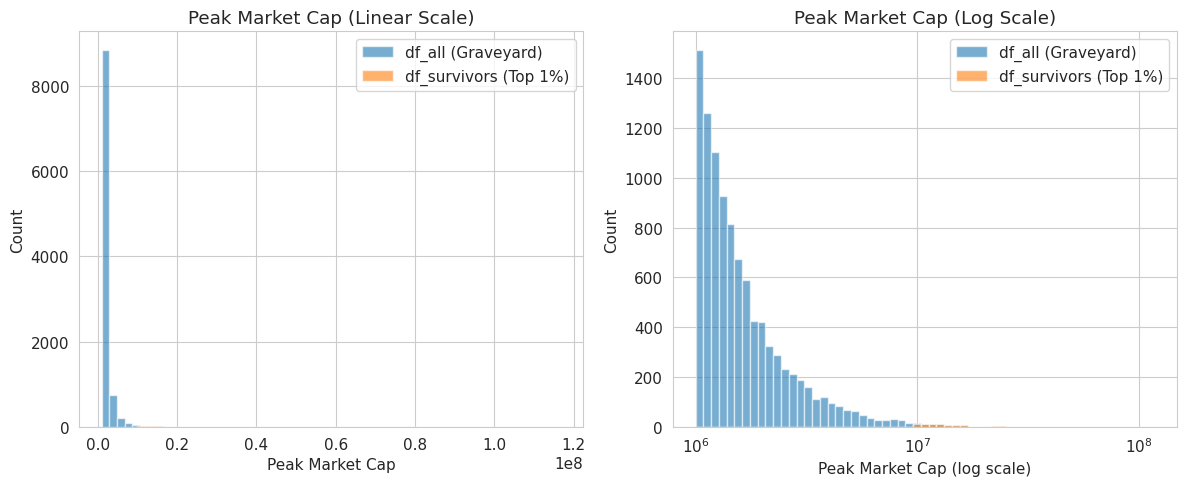

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_survivorship_bias(
    n_tokens: int = 10_000,
    survivor_pct: float = 0.01,      # top 1%
    alpha: float = 2.0,              # Pareto shape; lower => heavier tail
    scale: float = 1.0,              # base scale (will be scaled up)
    floor: float = 1e-12,            # near-zero floor for numerical stability
    mc_scale: float = 1e6,           # scale market caps to realistic-ish units
    random_seed: int = 42
):
    """
    Simulate peak market caps using a Pareto (power-law) distribution.

    Notes:
    - Pareto is heavy-tailed: many small values, a few huge winners.
    - Setting alpha moderately low (e.g., 1.5–2.5) makes the top tail dominate.
    - To force the intuition “99% are near zero,” we keep a tiny floor and use log-scale plots.
    """
    if not (0 < survivor_pct < 1):
        raise ValueError("survivor_pct must be between 0 and 1 (exclusive).")
    if alpha <= 1:
        # mean of Pareto does not exist for alpha <= 1; keep it > 1 for a finite mean
        raise ValueError("alpha must be > 1 so the mean exists and is interpretable.")

    rng = np.random.default_rng(random_seed)

    # Pareto variates: numpy's pareto(a) returns values on [0, inf) with tail ~ x^(-a-1)
    # Convert to standard Pareto Type I style by adding 1, then scale.
    pareto_raw = (rng.pareto(alpha, size=n_tokens) + 1.0) * scale

    # Convert to "Peak Market Cap" units and impose a tiny floor to emphasize near-zero mass.
    peak_market_cap = np.maximum(pareto_raw * mc_scale, floor)

    df_all = pd.DataFrame({
        "token_id": np.arange(1, n_tokens + 1),
        "peak_market_cap": peak_market_cap
    }).sort_values("peak_market_cap", ascending=False).reset_index(drop=True)

    # Top 1% survivors by peak market cap
    k = max(1, int(np.floor(n_tokens * survivor_pct)))
    df_survivors = df_all.head(k).copy()

    # Means (the punchline)
    mean_all = df_all["peak_market_cap"].mean()
    mean_survivors = df_survivors["peak_market_cap"].mean()

    print("=== Survivorship Bias Demo (Peak Market Cap) ===")
    print(f"Total tokens simulated: {n_tokens:,}")
    print(f"Survivors (top {survivor_pct*100:.2f}%): {k:,}")
    print(f"Pareto alpha (shape): {alpha}")
    print(f"Mean peak market cap (ALL / 'Graveyard'):      {mean_all:,.2f}")
    print(f"Mean peak market cap (SURVIVORS / top 1% only): {mean_survivors:,.2f}")
    print(f"Survivors mean ÷ All mean: {mean_survivors / mean_all:,.2f}x")

    # --- Visualization: dual histograms ---
    fig = plt.figure(figsize=(12, 5))

    # 1) Linear scale histogram (often looks like a spike at ~0 due to heavy tail)
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.hist(df_all["peak_market_cap"], bins=60, alpha=0.6, label="df_all (Graveyard)")
    ax1.hist(df_survivors["peak_market_cap"], bins=60, alpha=0.6, label="df_survivors (Top 1%)")
    ax1.set_title("Peak Market Cap (Linear Scale)")
    ax1.set_xlabel("Peak Market Cap")
    ax1.set_ylabel("Count")
    ax1.legend()

    # 2) Log scale histogram: makes “99% near zero” visually obvious
    # Use log-spaced bins for better readability across orders of magnitude.
    ax2 = fig.add_subplot(1, 2, 2)
    vmin = df_all["peak_market_cap"].min()
    vmax = df_all["peak_market_cap"].max()
    bins = np.logspace(np.log10(vmin), np.log10(vmax), 60)

    ax2.hist(df_all["peak_market_cap"], bins=bins, alpha=0.6, label="df_all (Graveyard)")
    ax2.hist(df_survivors["peak_market_cap"], bins=bins, alpha=0.6, label="df_survivors (Top 1%)")
    ax2.set_xscale("log")
    ax2.set_title("Peak Market Cap (Log Scale)")
    ax2.set_xlabel("Peak Market Cap (log scale)")
    ax2.set_ylabel("Count")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df_all, df_survivors

if __name__ == "__main__":
    # You can tweak alpha:
    # - alpha ~ 1.5: extremely heavy tail (winners dominate)
    # - alpha ~ 2.0: still very heavy tail
    # - alpha ~ 3.0: less extreme inequality
    df_all, df_survivors = simulate_survivorship_bias(
        n_tokens=10_000,
        survivor_pct=0.01,
        alpha=2.0,
        mc_scale=1e6,
        random_seed=42
    )